**Table of contents**<a id='toc0_'></a>    
- [Validating the simulation framework](#toc1_)    
  - [Continuous excitation](#toc1_1_)    
    - [Irradiance saturation of a two state system](#toc1_1_1_)    
      - [Simulation](#toc1_1_1_1_)    
      - [Calculation](#toc1_1_1_2_)    
    - [Second order coherence shows antibunching](#toc1_1_2_)    
  - [Multiple fluorophores](#toc1_2_)    
    - [Second order coherence shows less antibunching](#toc1_2_1_)    
    - [Additive fluorescence](#toc1_2_2_)    
    - [Multiple lifetime components](#toc1_2_3_)    
  - [Detailed photophysical models in FCS](#toc1_3_)    
    - [Widengren et al.: Fitting Cy5 FCS curve](#toc1_3_1_)    
      - [Simulation](#toc1_3_1_1_)    
      - [Fit](#toc1_3_1_2_)    
    - [Widengren et al.: Modulating irradiance for Cy5 FCS curve](#toc1_3_2_)    
  - [*d*STORM](#toc1_4_)    
    - [Gidi et al.: Concentration of MEA (or $\beta$-ME) has linear effect on T1 decay rate](#toc1_4_1_)    
    - [Gidi et al.: Increase in irradiance leads to shorter ON times](#toc1_4_2_)    
  - [Energy transfers](#toc1_5_)    
    - [Singlet-singlet annihilation restores antibunching](#toc1_5_1_)    
    - [homo-FRET](#toc1_5_2_)    
    - [Shorter fluorescence lifetime and less fluorescence](#toc1_5_3_)    
  - [TCSPC](#toc1_6_)    
    - [Second order coherence peaks at every between-pulse-time](#toc1_6_1_)    
    - [Long fluorescence lifetimes are seen as short fluorescence lifetimes (Aliasing)](#toc1_6_2_)    
  - [Figure](#toc1_7_)    
    - [Figure 1](#toc1_7_1_)    
    - [Figure 2](#toc1_7_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Validating the simulation framework](#toc0_)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.miscellaneous as mi
import fluopy.prediction as pr
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_3_validations"

## <a id='toc1_1_'></a>[Continuous excitation](#toc0_)

### <a id='toc1_1_1_'></a>[Irradiance saturation of a two state system](#toc0_)
Demonstrates a correct implementation of excitation rate calculation given an irradiance

#### <a id='toc1_1_1_1_'></a>[Simulation](#toc0_)

In [2]:
rng = np.random.default_rng(1)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
irradiances_saturation = np.logspace(-2, 5, 8)
photons_per_frame_collection_saturation = []
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
]
_, _, frequency = fo.convert_wavenumber_wavelength_frequency(wavelength=640)
for irradiance in irradiances_saturation:
    photon_flux = fo.calculate_photon_flux(
        irradiance=irradiance,
        frequency=frequency,
    )
    excitation_rate = fo.calculate_excitation_rate(
        photon_flux=photon_flux,
        absorption_cross_section=8.1e-16,
    )

    excitation = [
        tr.Transition(
            tr.TransitionType.EXCITATION,
            rate=excitation_rate,
            fluorophore_ids=[0],
        )
    ]
    transition_set = tr.TransitionSet(
        {"S0S1System": transitions + excitation}, fluorophore_system
    )
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e7, seed=rng)
    emissions = em.Emissions(seed=rng, frame_time="1ms")
    emissions.extract(simulation)
    photons_per_frame = emissions.event_time_series.mean()
    photons_per_frame_collection_saturation.append(photons_per_frame)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.73e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.73e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.73e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e

#### <a id='toc1_1_1_2_'></a>[Calculation](#toc0_)

In [3]:
k_s1 = 1.6e8 + 4.2e8
relative_photon_rate_collection_saturation = []
for irradiance in irradiances_saturation:
    photon_flux = fo.calculate_photon_flux(
        irradiance=irradiance,
        frequency=frequency,
    )
    excitation_rate = fo.calculate_excitation_rate(
        photon_flux=photon_flux,
        absorption_cross_section=8.1e-16,
    )
    relative_photon_rate = excitation_rate / (excitation_rate + k_s1)
    relative_photon_rate_collection_saturation.append(relative_photon_rate)

### <a id='toc1_1_2_'></a>[Second order coherence shows antibunching](#toc0_)
Demonstrates that a single fluorophore shows the expected antibunching drop indicating a proper implementation of excitation/fluorescence dynamics

In [4]:
rng = np.random.default_rng(2)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=4e6, seed=rng)
emissions = em.Emissions(seed=rng)
emissions.extract(simulation)
hist_antibunch, bins_antibunch = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.73e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


## <a id='toc1_2_'></a>[Multiple fluorophores](#toc0_)

### <a id='toc1_2_1_'></a>[Second order coherence shows less antibunching](#toc0_)
Demonstrates that multiple, non-interacting fluorophores have the expected effect on photon antibunching

In [5]:
rng = np.random.default_rng(3)
fluorophores = fl.construct_fluorophores(
    name="S0S1System", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S,
        rate=4.2e8,
        fluorophore_ids=[0, 1, 2, 3],
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0, 1, 2, 3]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0, 1, 2, 3],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=2e6, seed=rng)
emissions = em.Emissions(seed=rng)
emissions.extract(simulation)

hist_multi_f, bins_multi_f = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 4.31e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


### <a id='toc1_2_2_'></a>[Additive fluorescence](#toc0_)
Demonstrates that if no energy transfer or other disturbances, than the intensity scales proportional to the number of fluorophores

In [6]:
rng = np.random.default_rng(4)
num_fluorophores = [1, 2, 3, 4, 5, 6]
photons_per_frame_collection_num_f = []
for num in num_fluorophores:
    fluorophores = fl.construct_fluorophores(
        name="S0S1System", count=num, distance=3, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    ids = np.arange(num, dtype=int).tolist()
    transitions = [
        tr.Transition(
            tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=ids
        ),
        tr.Transition(
            tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=ids
        ),
        tr.Transition(
            tr.TransitionType.EXCITATION,
            rate=7.3e6,
            fluorophore_ids=ids,
        ),
    ]
    transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=2e6, seed=rng)
    emissions = em.Emissions(seed=rng)
    emissions.extract(simulation)
    photons_per_frame = emissions.event_time_series.mean()
    photons_per_frame_collection_num_f.append(photons_per_frame)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.73e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 8.63e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 

### <a id='toc1_2_3_'></a>[Multiple lifetime components](#toc0_)
If the fluorescence lifetimes differ (multiple *different* fluorophores) the fluoresence lifetime histogram should be multi-exponential

## <a id='toc1_3_'></a>[Detailed photophysical models in FCS](#toc0_)

### <a id='toc1_3_1_'></a>[Widengren et al.: Fitting Cy5 FCS curve](#toc0_)
Indicates the photophysical model to be implemented correctly (qualitatively speaking) and that the photon counting and subsequent FCS analysis are working properly

#### <a id='toc1_3_1_1_'></a>[Simulation](#toc0_)

In [7]:
rng = np.random.default_rng(5)
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = fluorophore_system.load_transitions(
    irradiance=5,
    bleaching=False,
    dstorm=False,
    wavelength=640,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
prediction = pr.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.run(size=2e6, seed=rng)
emissions = em.Emissions(seed=rng)
emissions.extract(simulation)

fcs_to_fit = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.70e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


#### <a id='toc1_3_1_2_'></a>[Fit](#toc0_)

In [8]:
s0_index = np.where(transition_set.single_states["cy5_dna"] == 0)[0][0]
s1_index = np.where(transition_set.single_states["cy5_dna"] == 1)[0][0]
excitation_rate = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "EXC"
]["rate"].values[0]
k_isc = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "ISC_ST"
]["rate"].values[0]
k_T = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "ISC_TS"
]["rate"].values[0]
k_iso = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "ISO"
]["rate"].values[0]
k_biso_1 = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "PBISO"
]["rate"].values[0]
k_biso_2 = transition_set.transition_df[
    transition_set.transition_df["abbreviation"] == "TBISO"
]["rate"].values[0]
k_biso_eff = k_biso_1 + k_biso_2
k_01 = 1 / prediction.mean_lifetimes["cy5_dna"][s0_index]
k_10 = 1 / prediction.mean_lifetimes["cy5_dna"][s1_index]

number_fluorophores = 1
antibunching = fcs_p.fit_antibunching(
    tau=fcs_to_fit.tau,
    excitation_rate=excitation_rate,
    s1_lifetime=prediction.mean_lifetimes["cy5_dna"][s1_index],
)
triplet_cis, norm = fcs_p.fit_triplet_cis(
    tau=fcs_to_fit.tau,
    k_isc=k_isc,
    k_T=k_T,
    k_01=k_01,
    k_10=k_10,
    k_iso=k_iso,
    k_biso_eff=k_biso_eff,
)
fit_combined = (antibunching + triplet_cis) / (norm * number_fluorophores) + 1

### <a id='toc1_3_2_'></a>[Widengren et al.: Modulating irradiance for Cy5 FCS curve](#toc0_)

In [9]:
rng = np.random.default_rng(6)
fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])
irradiances_fcs = [1, 10, 100]
fcs_irradiance = []
fcs_irradiance_2 = []
for irradiance in irradiances_fcs:
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates(
        {3: 5e5, 4: 1e7}
    )  # to resemble non-DNA oxygen-saturated conditions as in the original paper
    # transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()
    t1_index = np.where(transition_set.single_states["cy5_dna"] == 3)[0][0]
    cis_index = np.where(transition_set.single_states["cy5_dna"] == 6)[0][0]
    prediction = pr.Prediction(transition_set)
    print(f"T1 occupation: {prediction.state_occupations['cy5_dna'][t1_index]}")
    print(f"CIS occupation: {prediction.state_occupations['cy5_dna'][cis_index]}")
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=rng)
    emissions = em.Emissions(seed=rng)
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    fcs_irradiance.append(fcs)

    transition_set = transition_set.adjust_rates({3: 5e5, 4: 0})
    # transition_set = transition_set.adjust_rates({3:5e5})
    transition_set.finalize()
    t1_index = np.where(transition_set.single_states["cy5_dna"] == 3)[0][0]
    cis_index = np.where(transition_set.single_states["cy5_dna"] == 6)[0][0]
    prediction = pr.Prediction(transition_set)
    print(f"T1 occupation: {prediction.state_occupations['cy5_dna'][t1_index]}")
    print(f"CIS occupation: {prediction.state_occupations['cy5_dna'][cis_index]}")
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=rng)
    emissions = em.Emissions(seed=rng)
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions).autocorrelate_time_points(exp_max=-4, exp_min=-11)
    fcs_irradiance_2.append(fcs)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.68e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


T1 occupation: 0.0026860244955578985
CIS occupation: 0.6650308408226554


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.71e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


T1 occupation: 0.008154179995470304
CIS occupation: 0.0


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.68e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


...

T1 occupation: 0.07296171857743836
CIS occupation: 0.0


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.68e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


T1 occupation: 0.16830159453435495
CIS occupation: 0.5231229702951129


Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.71e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.


T1 occupation: 0.3555238996258411
CIS occupation: 0.0


## <a id='toc1_4_'></a>[*d*STORM](#toc0_)

### <a id='toc1_4_1_'></a>[Gidi et al.: Concentration of MEA (or $\beta$-ME) has linear effect on T1 decay rate](#toc0_)
Indicates that the transition model qualitatively approximates reality

In [10]:
rng = np.random.default_rng(7)
triplet_lifetimes = []
rs_concs = []
concentrations = np.arange(10, 150, 10)
for conc in concentrations:
    fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
    fluorophore_system = fl.FluorophoreSystem([fluorophore])
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=True,
        dstorm_parameters={"concentration": conc},
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=1e6, end_time=None, seed=rng)
    analysis = an.Analysis(simulation)
    triplet_lifetime = analysis.mean_lifetimes["cy5_dna"][2]
    triplet_lifetimes.append(triplet_lifetime)
    rs_conc = fo.henderson_hasselbalch_equation(ph=7.5, pka=9.0, concentration=conc)
    rs_concs.append(rs_conc)

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.70e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.70e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.70e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e

### <a id='toc1_4_2_'></a>[Gidi et al.: Increase in irradiance leads to shorter ON times](#toc0_)

In [11]:
rng = np.random.default_rng(8)
irradiances_on = np.arange(0.1, 1, 0.1)
on_times = []
for irradiance in irradiances_on:
    fluorophore = fl.Fluorophore(name="cy5_dna", position=[0, 0])
    fluorophore_system = fl.FluorophoreSystem([fluorophore])
    transitions = fluorophore_system.load_transitions(
        irradiance=irradiance,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=True,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    predict = pr.Prediction(transition_set)
    simulation = si.Simulation(transition_set)
    simulation.run(size=8e7, end_time=None, seed=rng)
    emissions = em.Emissions(seed=rng)
    emissions.extract(simulation)
    on_off_times, on_off_values = bl.get_off_statistics(simulation, 0)
    on_durations = on_off_times[on_off_values == 1]
    on_durations = on_durations[1::2] - on_durations[0::2]
    on_times.append(on_durations.mean())

Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e

## <a id='toc1_5_'></a>[Energy transfers](#toc0_)

### <a id='toc1_5_1_'></a>[Singlet-singlet annihilation restores antibunching](#toc0_)
Demonstrates that the energy transfer is working as expected

In [12]:
rng = np.random.default_rng(9)
fluorophores = fl.construct_fluorophores(
    name="S0S1System", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S,
        rate=4.2e8,
        fluorophore_ids=[0, 1, 2, 3],
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0, 1, 2, 3]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0, 1, 2, 3],
    ),
]
et_transitions_1 = [
    tr.Transition(
        tr.TransitionType.S_S_ANNIHILATION,
        rate=1e11,
        fluorophore_ids=[
            (0, 1),
            (0, 2),
            (1, 3),
            (2, 3),
            (1, 0),
            (2, 0),
            (3, 1),
            (3, 2),
        ],
    ),
]
et_transitions_2 = [
    tr.Transition(
        tr.TransitionType.S_S_ANNIHILATION,
        rate=1e11,
        fluorophore_ids=[
            (0, 3),
            (1, 2),
            (3, 0),
            (2, 1),
        ],
    )
]
transitions = {
    "S0S1System": transitions,
    f"D: S0S1System, A: S0S1System, dist: {3.0}": et_transitions_1,
    f"D: S0S1System, A: S0S1System, dist: {4.243}": et_transitions_2,
}
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
simulation = si.Simulation(transition_set)
simulation.run(size=2e6, seed=rng)
emissions = em.Emissions(seed=rng)
emissions.extract(simulation)

hist_ssa, bins_ssa = fcs_p.coincidence(
    emissions.event_time_points, 1e-7, 1e-10, seed=rng
)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 8.32e-16.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+00 - 1.00e+01.


### <a id='toc1_5_2_'></a>[homo-FRET](#toc0_)
see Chapter III

### <a id='toc1_5_3_'></a>[Shorter fluorescence lifetime and less fluorescence](#toc0_)
Best shown if energy transfer partners are different

In [13]:
rng = np.random.default_rng(10)
distances = [3, 4, 5, 6, 7, 8, 9, 10]
photons_per_frame_collection_distances = []
lifetime_collection = []
for distance in distances:
    fluorophore_1 = fl.Fluorophore(name="S0S1System", position=[0, 0])
    fluorophore_2 = fl.Fluorophore(name="acceptor", position=[distance, 0])
    fluorophore_system = fl.FluorophoreSystem(
        fluorophores=[fluorophore_1, fluorophore_2]
    )
    transition_1 = tr.Transition(
        tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0]
    )
    transition_2 = tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1e9, fluorophore_ids=[0]
    )
    FRET_rate = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=1e9,
        spectral_overlap_integral=1e16,
    )
    transition_3 = tr.Transition(
        tr.TransitionType.FRET, rate=FRET_rate, fluorophore_ids=[(0, 1)]
    )
    transition_4 = tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=1e9, fluorophore_ids=[1]
    )
    transitions = {
        "S0S1System": [transition_1, transition_2],
        "acceptor": [transition_4],
        f"D: S0S1System, A: acceptor, dist: {float(distance)}": [transition_3],
    }
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(size=2e6, seed=rng)
    analysis = an.Analysis(simulation)
    fluorescence_lifetime = analysis.mean_lifetimes["S0S1System"][1]
    lifetime_collection.append(fluorescence_lifetime)
    emissions = em.Emissions(seed=rng)
    emissions.extract(simulation)
    photons_per_frame = emissions.event_time_series.mean()
    photons_per_frame_collection_distances.append(photons_per_frame)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore acceptor in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 3.88e-15.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 0].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+01 - 1.00e+02.
There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
There is no FluorophoreData for Fluorophore acceptor in fluopy.fluo_data. Parameters have to be defined manually.
Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 2.14e-14.
 This was estimated using the highest possible rate which occurs for example i

## <a id='toc1_6_'></a>[TCSPC](#toc0_)

### <a id='toc1_6_1_'></a>[Second order coherence peaks at every between-pulse-time](#toc0_)
Demonstrates that pulsed excitation is working

In [14]:
rng = np.random.default_rng(11)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
emis = em.Emissions(frame_time="1ms", bandpass=None, seed=rng)
Da, D, lifetimes_all, _ = emis.tcspc(
    transition_set,
    number_pulses=2e6,
    excitation_rates={"S0S1System": 3.75e9},
    time_between_pulses=12.5e-9,
    store_time_points=True,
)
hist_tcspc, bins_tcspc = fcs_p.coincidence(
    emis.event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng
)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
the last frame (of index 0.025) has 1.00e+00 times the pulses of other frames.


### <a id='toc1_6_2_'></a>[Long fluorescence lifetimes are seen as short fluorescence lifetimes (Aliasing)](#toc0_)
This is expected to create a skew towards short durations in the histogram

In [15]:
rng = np.random.default_rng(12)
fluorophore = fl.Fluorophore(name="S0S1System", position=[0, 0])
fluorophore_system = fl.FluorophoreSystem(fluorophores=[fluorophore])
transitions = [
    tr.Transition(
        tr.TransitionType.INTERNAL_CONVERSION_S, rate=4.2e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.FLUORESCENT_EMISSION, rate=1.6e8, fluorophore_ids=[0]
    ),
    tr.Transition(
        tr.TransitionType.EXCITATION,
        rate=7.3e6,
        fluorophore_ids=[0],
    ),
]
transition_set = tr.TransitionSet({"S0S1System": transitions}, fluorophore_system)
transition_set.finalize()
emis = em.Emissions(frame_time="1ms", bandpass=None, seed=rng)
Da, D, lifetimes_alias_1, _ = emis.tcspc(
    transition_set,
    number_pulses=2e6,
    excitation_rates={"S0S1System": 3.75e9},
    time_between_pulses=12.5e-9,
    store_time_points=True,
)
Da, D, lifetimes_alias_2, _ = emis.tcspc(
    transition_set,
    number_pulses=2e6,
    excitation_rates={"S0S1System": 3.75e9},
    time_between_pulses=1e-9,
    store_time_points=True,
)

There is no FluorophoreData for Fluorophore S0S1System in fluopy.fluo_data. Parameters have to be defined manually.
the last frame (of index 0.025) has 1.00e+00 times the pulses of other frames.
the last frame (of index 0.002) has 0.00e+00 times the pulses of other frames.


## <a id='toc1_7_'></a>[Figure](#toc0_)

### <a id='toc1_7_1_'></a>[Figure 1](#toc0_)

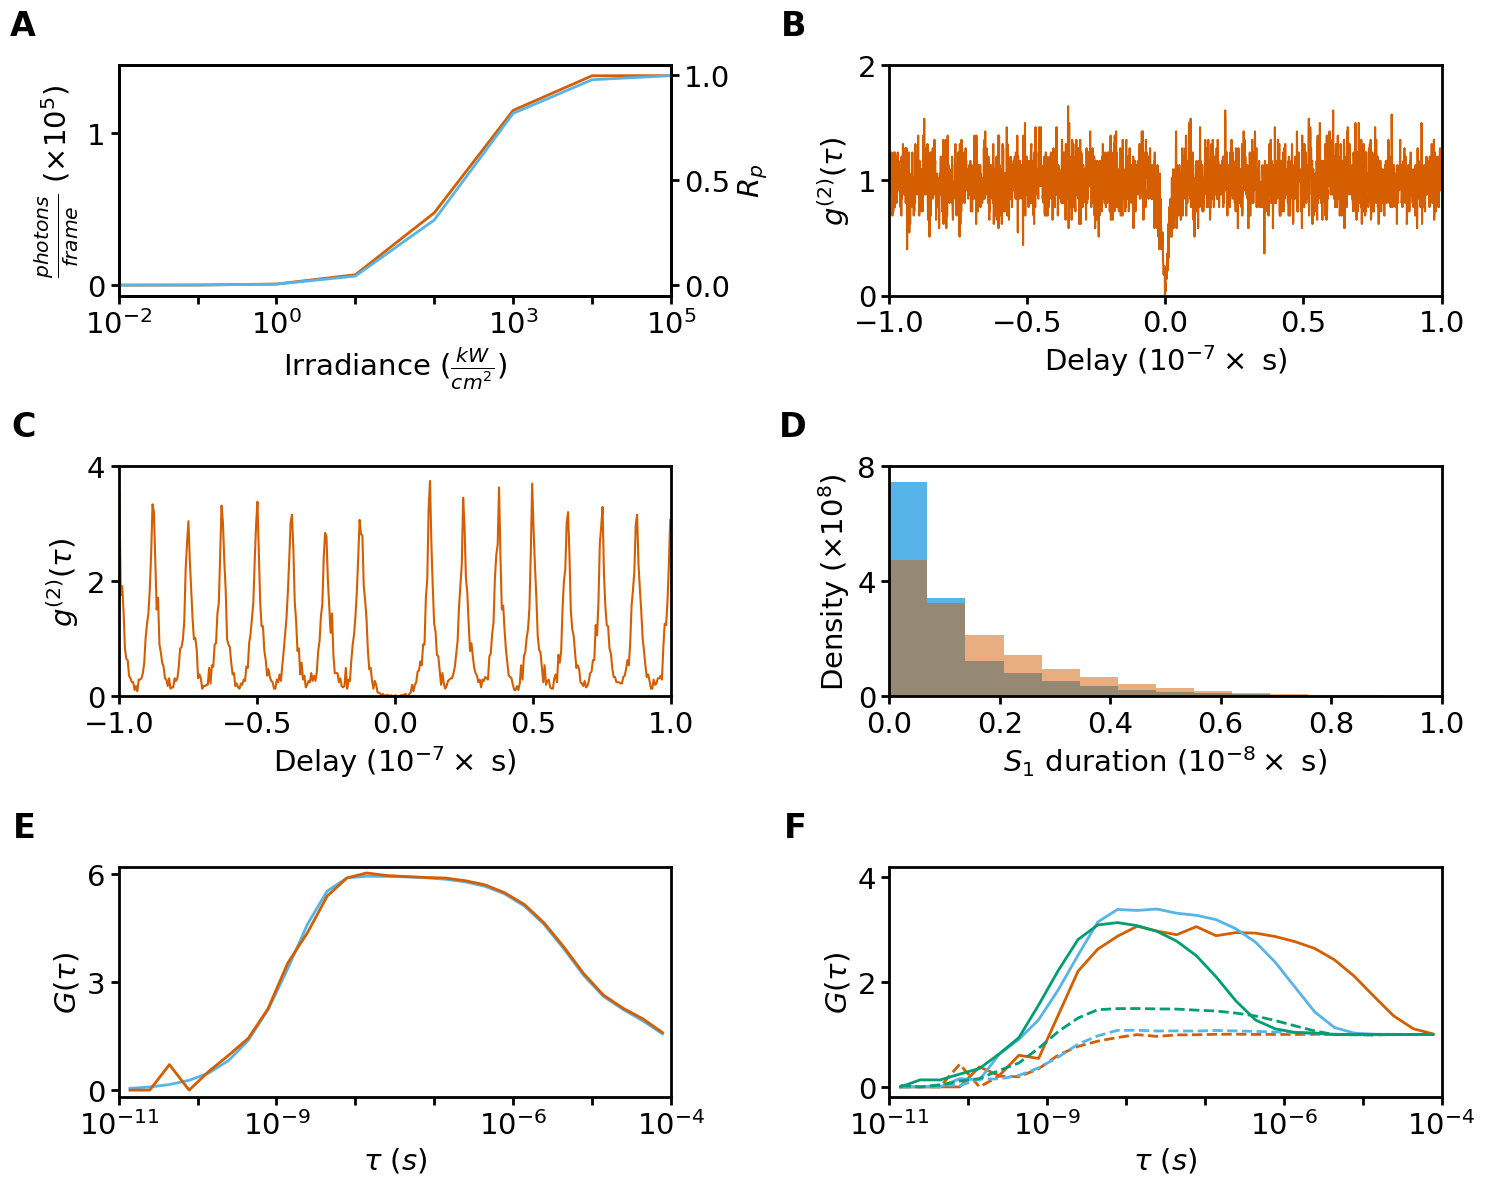

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 2)
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(gs[0, 0])
ax1_2 = ax1.twinx()
fi.universal_figure(
    axes=ax1,
    type_="line",
    data=[irradiances_saturation, photons_per_frame_collection_saturation],
    color=red,
    ylabel=r"$\frac{photons}{frame}$",
    xlabel=r"Irradiance ($\frac{kW}{cm^{2}}$)",
    tick_style_y="sci",
    lw=2,
)
fi.universal_figure(
    axes=ax1_2,
    type_="line",
    data=[irradiances_saturation, relative_photon_rate_collection_saturation],
    color=sky_blue,
    xscale="log",
    yscale="linear",
    ylabel=r"$R_p$",
    xlim=[1e-2, 1e5],
    xticks=[1e-2, 1e-1, 1e0, 1e1, 1e2, 1e3, 1e4, 1e5],
    xticklabels=dict(
        labels=[r"$10^{-2}$", "", r"$10^{0}$", "", "", r"$10^{3}$", "", r"$10^{5}$"]
    ),
    lw=2,
)
ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    axes=ax2,
    type_="line",
    data=[bins_antibunch, hist_antibunch],
    ylim=[0, 2],
    xlim=[-1e-7, 1e-7],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
)
ax3 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    axes=ax3,
    type_="line",
    data=[bins_tcspc, hist_tcspc],
    ylim=[0, 4],
    xlim=[-1e-7, 1e-7],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
)
ax4 = fig.add_subplot(gs[1, 1])
bins = np.linspace(0, 2e-8, 30)
fi.universal_figure(
    axes=ax4,
    type_="hist",
    data=lifetimes_alias_2,
    color=sky_blue,
    bins=bins,
    density=True,
)
fi.universal_figure(
    axes=ax4,
    type_="hist",
    data=lifetimes_alias_1,
    color=red,
    bins=bins,
    ylabel="Density",
    xlabel=r"$S_1$ duration (s)",
    alpha=0.5,
    density=True,
    tick_style_y="sci",
    tick_style_x="sci",
    xlim=[0, 1e-8],
    ylim=[0, 8e8],
    yticks=[0, 4e8, 8e8],
)
ax5 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    axes=ax5,
    type_="line",
    data=[fcs_to_fit.tau, fit_combined],
    label="fit",
    color=sky_blue,
    lw=2,
)
fcs_to_fit.plot(
    axes=ax5,
    color=red,
    label="simulation",
    title=None,
    lw=2,
    xlim=[1e-11, 1e-4],
    ylim=[-0.2, 6.2],
    xticks=[1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4],
    xticklabels=dict(
        labels=[r"$10^{-11}$", "", r"$10^{-9}$", "", "", r"$10^{-6}$", "", r"$10^{-4}$"]
    ),
    yticks=[0, 3, 6],
)

ax6 = fig.add_subplot(gs[2, 1])
for i, (fcs, fcs2) in enumerate(zip(fcs_irradiance, fcs_irradiance_2)):
    fcs.plot(
        axes=ax6,
        color=colors[i],
        label=f"{irradiances_fcs[i]} kW/cm²",
        legend=False,
        title=None,
        legendargs=dict(
            framealpha=1,
            edgecolor="black",
            fancybox=False,
        ),
        lw=2,
    )
    fcs2.plot(
        axes=ax6,
        color=colors[i],
        linestyle="--",
        title=None,
        lw=2,
        xlim=[1e-11, 1e-4],
        ylim=[-0.2, 4.2],
        xticks=[1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4],
        xticklabels=dict(
            labels=[
                r"$10^{-11}$",
                "",
                r"$10^{-9}$",
                "",
                "",
                r"$10^{-6}$",
                "",
                r"$10^{-4}$",
            ]
        ),
        yticks=[0, 2, 4],
    )

axes = fig.get_axes()
letters = ["A", "", "B", "C", "D", "E", "F"]
for i, axis in enumerate(axes):
    offset = -0.15
    axis.text(
        offset,
        1.1,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    saving_at + r"\validations_1.png",
    dpi=300,
    bbox_inches=bbox,
)

### <a id='toc1_7_2_'></a>[Figure 2](#toc0_)

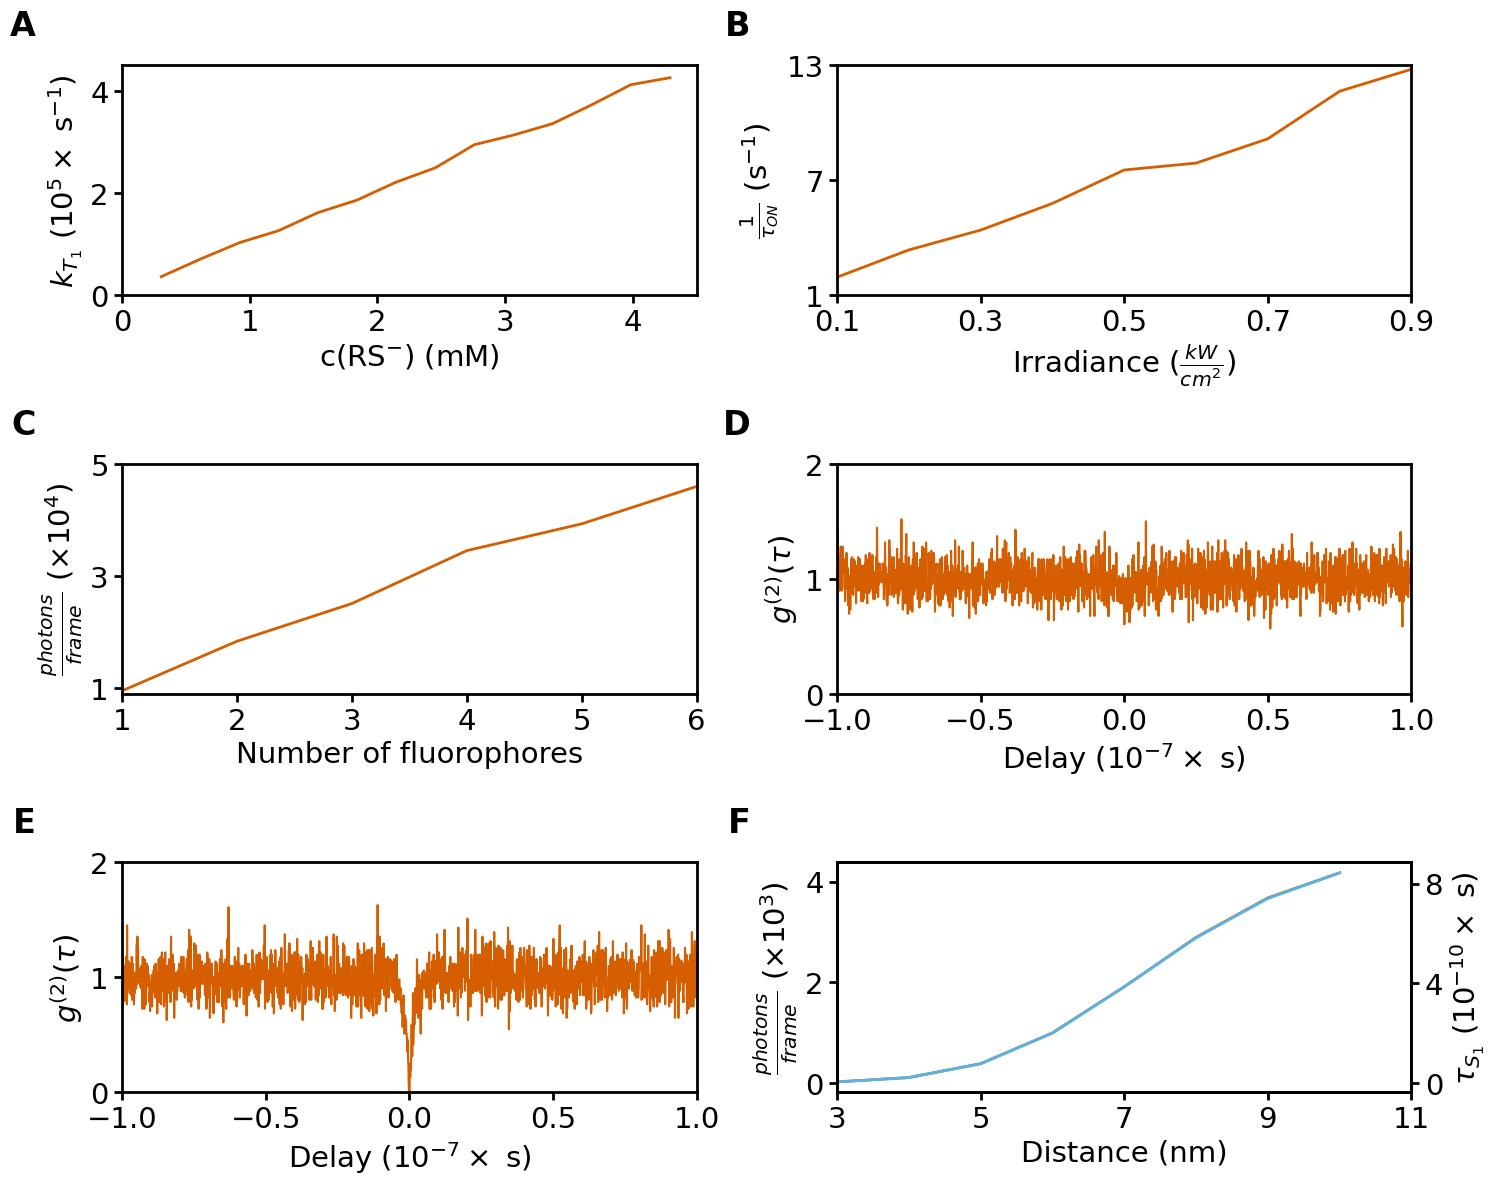

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 2)
fig = plt.figure(figsize=(15, 12))

ax1 = fig.add_subplot(gs[0, 0])
fi.universal_figure(
    axes=ax1,
    type_="line",
    lw=2,
    data=[rs_concs, 1 / np.array(triplet_lifetimes)],
    color=red,
    ylabel=r"$k_{T_{1}}$ (s$^{-1}$)",
    xlabel=r"c(RS$^{-}$) (mM)",
    tick_style_y="sci",
    xlim=[0, 4.5],
    ylim=[0, 4.5e5],
    xticks=[0, 1, 2, 3, 4],
    yticks=[0, 2e5, 4e5],
)
ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    axes=ax2,
    type_="line",
    lw=2,
    data=[irradiances_on, 1 / np.array(on_times)],
    color=red,
    ylabel=r"$\frac{1}{\tau_{ON}}$ (s$^{-1}$)",
    xlabel=r"Irradiance ($\frac{kW}{cm^{2}}$)",
    xlim=[0.1, 0.9],
    xticks=[0.1, 0.3, 0.5, 0.7, 0.9],
    ylim=[1, 13],
    yticks=[1, 7, 13],
)
ax3 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    axes=ax3,
    type_="line",
    lw=2,
    data=[num_fluorophores, photons_per_frame_collection_num_f],
    color=red,
    ylabel=r"$\frac{photons}{frame}$",
    xlabel="Number of fluorophores",
    tick_style_y="sci",
    xlim=[1, 6],
    xticks=[1, 2, 3, 4, 5, 6],
    ylim=[9e3, 5e4],
    yticks=[1e4, 3e4, 5e4],
)
ax4 = fig.add_subplot(gs[1, 1])
fi.universal_figure(
    axes=ax4,
    type_="line",
    data=[bins_multi_f, hist_multi_f],
    ylim=[0, 2],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
    xlim=[-1e-7, 1e-7],
)
ax5 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    axes=ax5,
    type_="line",
    data=[bins_ssa, hist_ssa],
    ylim=[0, 2],
    ylabel=r"$g^{(2)}(\tau)$",
    xlabel="Delay (s)",
    color=red,
    tick_style_x="sci",
    xlim=[-1e-7, 1e-7],
)
ax6 = fig.add_subplot(gs[2, 1])
ax6_2 = ax6.twinx()
fi.universal_figure(
    axes=ax6,
    type_="line",
    lw=2,
    data=[distances, photons_per_frame_collection_distances],
    color=red,
    ylabel=r"$\frac{photons}{frame}$",
    xlabel="Distance (nm)",
    tick_style_y="sci",
)
fi.universal_figure(
    axes=ax6_2,
    type_="line",
    lw=2,
    data=[distances, lifetime_collection],
    color=sky_blue,
    ylabel=r"$\tau_{S_{1}}$ (s)",
    xlabel="Distance (nm)",
    tick_style_y="sci",
    xlim=[3, 11],
    xticks=[3, 5, 7, 9, 11],
    yticks=[0, 4e-10, 8e-10],
)

axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", ""]
for i, axis in enumerate(axes):
    offset = -0.15
    axis.text(
        offset,
        1.1,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()

bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)

fig.savefig(
    saving_at + r"\validations_2.png",
    dpi=300,
    bbox_inches=bbox,
)